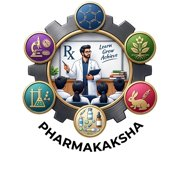

# BP801T · Unit II — Regulatory Framework and Explainable AI
**Pharmakaksha · Learn · Grow · Achieve**
*Ethical Considerations and Translational Applications of AI in Pharmacy · B.Pharm Semester VIII · PCI NEP 2020*

This notebook contains every example and demo from the Unit II study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit2_Regulation_and_Explainable_AI.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/BP801T_Unit2_Regulation_and_Explainable_AI.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The models are for learning only. They are not clinical, regulatory or legal tools.

> Regulatory facts in this notebook are summarised for teaching, as of October 2026. Always read the current official text before a real submission.

## 2.1 AI in regulatory submissions
Regulators do not approve "AI" in general. They judge whether a model is **credible for one specific job**. FDA's draft guidance *Considerations for the Use of AI to Support Regulatory Decision-Making for Drug and Biological Products* (January 2025) gives a **7-step risk-based credibility framework**:

1. Define the **question of interest**
2. Define the **context of use (COU)** — what the model does and how its output is used
3. Assess **model risk** = model influence × decision consequence
4. Develop a **credibility assessment plan**
5. **Execute** the plan
6. **Document** the results and any deviations
7. Decide whether the model is **adequate** for the COU

Step 3 is a simple grid. Model **influence** = how much the AI output drives the decision (alone, or checked by other evidence). **Decision consequence** = how bad a wrong decision would be for patients.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP801T%20Ethical%20Considerations%20and%20Translational%20Applications%20of%20AI%20in%20Pharmacy%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

TEAL, GREEN, ORANGE, GREY = "#12303A", "#1F8A70", "#E07A2E", "#8A9BA3"
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def model_risk(influence, consequence):
    """FDA-style model risk from influence and consequence (each 'low', 'medium' or 'high')."""
    score = {"low": 1, "medium": 2, "high": 3}
    s = score[influence] + score[consequence]
    return "High" if s >= 5 else "Medium" if s >= 4 else "Low"

examples = [
    ("AI flags tablets for a human QC check; lab assay still decides batch release", "low", "medium"),
    ("AI predicts which trial patients need ECG monitoring; no other check", "high", "high"),
    ("AI drafts literature summaries reviewed by a medical writer", "low", "low"),
    ("AI decides PK sampling times; PK is also confirmed by standard analysis", "medium", "medium"),
]
for text, inf, con in examples:
    print(f"{model_risk(inf, con):<6} | influence={inf:<6} consequence={con:<6} | {text}")

The higher the model risk, the more evidence the sponsor must show: larger and more independent test data, subgroup results, uncertainty, and a plan to monitor the model over its life.

## 2.2 Explainable AI (XAI)
A regulator, a pharmacist and a patient all ask the same question: **why did the model say that?** Explainable AI answers it in two ways:

| | **Global** — how the model works overall | **Local** — why this one prediction |
|---|---|---|
| **Intrinsic** (glass-box model) | Logistic regression odds ratios; decision-tree rules | Each feature's contribution for one patient |
| **Post-hoc** (any model) | Permutation importance; partial dependence | SHAP values; LIME; counterfactuals |

We reuse the ADR dataset from Unit I and the same cleaning steps.

In [ ]:
ehr = load("adr_ehr.csv").drop_duplicates()
ehr["sex"] = ehr["sex"].str.upper().str[0]
ehr.loc[ehr["age"] > 120, "age"] //= 10
ehr.loc[ehr["weight_kg"] > 300, "weight_kg"] /= 100
ehr["female"] = (ehr["sex"] == "F").astype(int)
ehr["egfr"] = ehr["egfr"].fillna(ehr["egfr"].median())
dev = ehr[ehr["admission_date"] < "2025"]

FEATURES = ["age", "female", "weight_kg", "egfr", "num_drugs",
            "on_anticoagulant", "prior_adr", "liver_disease"]
X, y = dev[FEATURES], dev["adr"]
print(X.shape, "ADR rate:", round(y.mean(), 3))

### Glass-box model 1 — logistic regression and odds ratios
An **odds ratio (OR)** above 1 raises the odds of an ADR; below 1 lowers it. The 95% confidence interval (CI) shows how sure we are.

In [ ]:
import statsmodels.api as sm

logit = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
OR = pd.DataFrame({"odds_ratio": np.exp(logit.params), "CI_low": np.exp(logit.conf_int()[0]),
                   "CI_high": np.exp(logit.conf_int()[1]), "p_value": logit.pvalues}).drop("const")
print(OR.round(3).sort_values("odds_ratio", ascending=False))

Reading it: being **on an anticoagulant** multiplies the odds of an ADR by about 3.3, **liver disease** by 2.7 and a **prior ADR** by 2.4. Each **extra drug** multiplies the odds by 1.14. Each extra mL/min of **eGFR** gives an OR of 0.96, so an eGFR 10 mL/min lower raises the odds by about 46%. Age is not significant here because its effect is already carried by eGFR, which falls with age. Anyone can check these against pharmacology. That is what makes the model **interpretable**.

### Glass-box model 2 — a shallow decision tree
A tree of depth 3 can be printed as plain **if–then rules**.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, random_state=42).fit(X, y)
print(export_text(tree, feature_names=FEATURES, decimals=0, show_weights=True))

Each leaf shows `weights: [no ADR, ADR]` — the number of training patients of each kind who end up there. For example, the path **eGFR ≤ 80 → weight ≤ 69 kg → more than 6 drugs** collects the highest share of ADRs. A pharmacist can read and challenge every rule.

### Post-hoc explanation — a random forest and permutation importance
A random forest of 300 trees is a **black box**: nobody can read 300 trees. **Permutation importance** explains it from outside: shuffle one feature and measure how much the AUC drops. A big drop means the model relies on that feature.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=42).fit(X_tr, y_tr)
imp = permutation_importance(forest, X_te, y_te, scoring="roc_auc", n_repeats=20, random_state=42)
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values()

plt.barh(importance.index, importance.values, color=GREEN)
plt.xlabel("Drop in AUC when the feature is shuffled")
plt.title("Permutation importance — what the forest relies on")
plt.tight_layout(); plt.show()

**The interpretability trade-off.** Is the black box worth it? Compare the three models with 5-fold cross-validation.

In [ ]:
models = {
    "Logistic regression (glass box)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Decision tree, depth 3 (glass box)": DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, random_state=42),
    "Random forest, 300 trees (black box)": RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=42),
}
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=cv, scoring="roc_auc")
    print(f"{name:<38} AUC = {s.mean():.3f} ± {s.std():.3f}")

Here the glass-box logistic regression is **as good as** the black box. When a simpler, explainable model performs as well, regulators and clinicians will prefer it. Use a black box only when it is clearly better, and then explain it with post-hoc tools.

### Local explanation — why is *this* patient high-risk?
For a logistic regression, each feature's contribution to one patient's log-odds is **coefficient × (patient value − average value)**. For a linear model these are exactly the **SHAP values** (Shapley additive explanations): they add up from the average risk to this patient's risk.

In [ ]:
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X, y)
scaler, clf = lr.named_steps["standardscaler"], lr.named_steps["logisticregression"]

patient = X.loc[[dev.index[(dev["num_drugs"] >= 8) & (dev["egfr"] < 45)][0]]]
print(patient.T.rename(columns=lambda c: "value"))
contrib = pd.Series(clf.coef_[0] * scaler.transform(patient)[0], index=FEATURES)
base = clf.intercept_[0]
risk = 1 / (1 + np.exp(-(base + contrib.sum())))
print(f"\nAverage-patient risk = {1 / (1 + np.exp(-base)):.1%}   This patient = {risk:.1%}")

In [ ]:
c = contrib.sort_values()
plt.barh(c.index, c.values, color=[ORANGE if v > 0 else GREEN for v in c.values])
plt.axvline(0, color=TEAL, linewidth=1)
plt.xlabel("Contribution to log-odds of ADR  (orange raises risk, green lowers it)")
plt.title(f"Local explanation for one patient (risk {risk:.0%})")
plt.tight_layout(); plt.show()

**Counterfactual explanation:** "what would have to change for the risk to fall below 20%?" Pharmacists can act on this, e.g. through deprescribing.

In [ ]:
for fewer in range(0, 7):
    p = patient.copy()
    p["num_drugs"] = patient["num_drugs"].values[0] - fewer
    r = lr.predict_proba(p)[0, 1]
    print(f"{int(p['num_drugs'].values[0]):>2} drugs -> predicted risk {r:.1%}")
    if r < 0.20:
        break

Removing six drugs only just brings this patient below 20%. The explanation tells the pharmacist that the risk comes mainly from **low eGFR and age**, which cannot be changed, so renal dose adjustment and closer monitoring matter more than deprescribing alone.

> A counterfactual describes the **model**, not a proven cause. Clinical decisions still need clinical judgement.

## 2.3 Transparency and interpretability
- **Transparency** = openness about the system: its purpose, data, performance, limits and who is responsible (a model card, labelling, an audit trail).
- **Interpretability** = a human can understand how inputs lead to outputs.
- **Explainability** = we can give a reason for a specific output, even for a black box (post-hoc).

## 2.4 The rulebooks: EU AI Act, FDA and CDSCO
**EU AI Act** (Regulation (EU) 2024/1689) sorts AI into four risk tiers. As amended by the 2026 Digital Omnibus, high-risk duties apply from 2 Dec 2027 (Annex III uses) and 2 Aug 2028 (AI inside regulated products such as medical devices).

In [ ]:
def eu_ai_act_tier(use):
    tiers = {
        "social scoring of citizens": "Unacceptable — banned",
        "AI-based diagnostic software (medical device needing a notified body)": "High risk — conformity assessment, risk management, data governance, human oversight, logging",
        "AI triage of emergency calls": "High risk",
        "pharmacy chatbot answering customers": "Limited risk — must tell users they are talking to an AI",
        "AI-generated health awareness video": "Limited risk — label as AI-generated",
        "spam filter in the pharmacy email": "Minimal risk — no extra duties",
    }
    return tiers.get(use, "Check Article 5, Article 6 and Annexes I and III")

for u in ["social scoring of citizens", "AI-based diagnostic software (medical device needing a notified body)",
          "pharmacy chatbot answering customers", "spam filter in the pharmacy email"]:
    print(f"{u:<72} -> {eu_ai_act_tier(u)}")

**CDSCO (India).** The *Guidance Document on Medical Device Software* (21 July 2026), under the Medical Devices Rules 2017, classes standalone software (SaMD) from A (lowest risk) to D (highest), using an IMDRF-style grid: how serious the patient's situation is × how much the software's information matters to the decision.

In [ ]:
CDSCO_GRID = {
    "critical":    {"treat or diagnose": "D", "drive management": "C", "inform management": "B"},
    "serious":     {"treat or diagnose": "C", "drive management": "B", "inform management": "A"},
    "non-serious": {"treat or diagnose": "B", "drive management": "A", "inform management": "A"},
}
cases = [
    ("App that detects sepsis in ICU patients and triggers treatment", "critical", "treat or diagnose"),
    ("Software that suggests insulin dose adjustments to doctors", "serious", "drive management"),
    ("Dashboard that shows a patient's past BP readings to a GP", "serious", "inform management"),
    ("Acne photo app that recommends OTC products", "non-serious", "drive management"),
]
for text, situation, role in cases:
    print(f"Class {CDSCO_GRID[situation][role]} | {situation:<11} | {role:<17} | {text}")

## 2.5 Accountability in automated decisions
When an AI recommendation harms a patient, someone must be answerable. Three practical tools make accountability real:
1. **Human in the loop** — a named professional accepts or overrides the AI.
2. **Audit trail** — every prediction is logged with model version, inputs, output, time and the human decision.
3. **Override monitoring** — if humans override the AI very often (or never), investigate.

In [ ]:
from datetime import datetime, timedelta

log = []
t0 = datetime(2026, 10, 1, 9, 0)
decisions = ["accepted", "accepted", "overridden", "accepted", "accepted", "accepted"]
for i, idx in enumerate(X_te.index[:6]):
    r = float(lr.predict_proba(X_te.loc[[idx]])[0, 1])
    log.append({"time": (t0 + timedelta(minutes=7 * i)).strftime("%Y-%m-%d %H:%M"),
                "patient": dev.loc[idx, "patient_id"], "model_version": "ADR-risk v1.0",
                "risk": round(r, 2), "ai_advice": "Review" if r >= 0.2 else "Routine",
                "pharmacist": "PharmD-017", "decision": decisions[i]})
audit_trail = pd.DataFrame(log)
print(audit_trail.to_string(index=False))
print("\nOverride rate:", round((audit_trail["decision"] == "overridden").mean() * 100), "%")

## 2.6 Risk-based classification — one idea, three regulators
| Framework | Risk is judged by | Levels |
|---|---|---|
| EU AI Act | The **use** of the AI system | Unacceptable / High / Limited / Minimal |
| FDA (drugs, 2025 draft) | Model influence × decision consequence | Low / Medium / High model risk |
| FDA (devices) | Device class and pathway; PCCP for planned AI updates | Class I / II / III |
| CDSCO (MDSW 2026) | Patient situation × significance of the information | Class A / B / C / D |

All of them share one principle: **the higher the risk to patients, the stronger the evidence, oversight and monitoring required.**

## Quick check
A hospital uses an AI tool that **independently decides** to stop chemotherapy doses when it predicts severe neutropenia. What is the model risk in FDA's grid? Decide, then run the cell.

In [ ]:
print(model_risk("high", "high"), "— high influence (no human check) and high consequence (cancer treatment).")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Use `model_risk()` for an AI that **predicts tablet dissolution** to support a formulation change, where dissolution is **also tested in the lab** (influence low) and a wrong answer could release a sub-standard batch (consequence high).

**2.** Fit a decision tree with `max_depth=2`. Print its rules. Which feature is used first?

**3.** Compute the permutation importance of the **logistic regression** `lr` on `X_te, y_te`. Is the ranking similar to the forest?

**4.** Classify with `CDSCO_GRID`: software that **diagnoses diabetic retinopathy** from eye photos for screening in a serious (not critical) situation.

---
## Solutions

In [ ]:
# 1
print(model_risk("low", "high"))   # Medium: the lab test limits the AI's influence

In [ ]:
# 2
t2 = DecisionTreeClassifier(max_depth=2, min_samples_leaf=30, random_state=42).fit(X, y)
print(export_text(t2, feature_names=FEATURES, decimals=0, show_weights=True))   # eGFR is used first

In [ ]:
# 3
imp_lr = permutation_importance(lr, X_te, y_te, scoring="roc_auc", n_repeats=20, random_state=42)
print(pd.Series(imp_lr.importances_mean, index=FEATURES).sort_values(ascending=False).round(3))

In [ ]:
# 4
print("Class", CDSCO_GRID["serious"]["treat or diagnose"])

---
**Next:** Unit III — AI in Pharmacy Automation and Supply Chain. Pharmakaksha · Learn · Grow · Achieve